# Diabetes Risk Prediction - Análise e Classificação de dados usando Scikit-Learn, Pandas e Seaborn.

por Pedro Arthur Gomes Maia

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Bibliotecas importadas")

Bibliotecas importadas


Importando o dataset.

In [2]:
data = pd.read_csv("diabetes_risk.csv")
print("Dataset importado")

Dataset importado


# Análise e Exploração dos Dados

In [3]:
data.shape

(15000, 19)

In [4]:
data.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='str')

In [5]:
numeric = data.select_dtypes(include=["number"]).columns
categorical = data.select_dtypes(exclude=["number"]).columns

print("Numéricas: ")
print(numeric)

print("Categóricas: ")
print(categorical)

Numéricas: 
Index(['patient_id', 'age', 'bmi', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm'],
      dtype='str')
Categóricas: 
Index(['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
       'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket',
       'diabetes_risk'],
      dtype='str')


In [6]:
data.head(10)

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
5,6,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
6,7,42,Female,Hyderabad,22.5,No,Sedentary,Non-Vegetarian,NaN,NaN,7.0,10,190,7.5,140,81,95.0,High,Moderate
7,8,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
8,9,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate
9,10,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate


In [7]:
data.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [8]:
data.describe(include=['object'])

/tmp/ipykernel_20455/1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,gender,city,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,income_bracket,diabetes_risk
count,15000,15000,15000,15000,15000,14528,11212,14537,15000
unique,3,18,2,3,4,3,3,3,3
top,Male,Mumbai,No,Active,Non-Vegetarian,Never,Never,Middle,Low
freq,7664,2243,9756,5100,8195,10119,5616,7305,9000


In [9]:
# Checando se há linhas com dados faltando, ou dados duplicados.
print(data.isna().sum())
print(data.duplicated().sum())

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64


0


Para lidar com as colunas sem valor, irei apenas desconsiderar as linhas com esses valores, já que esse dataset será utilizado para treinar alguns modelos de classificação.

Além disso, irei desconsiderar a coluna "patient_id", pois pode ser apenas representada pelo index da coluna.

In [10]:
data = data.dropna()
data = data.drop(columns=["patient_id"])
print(data.shape)

(10500, 18)


In [11]:
sns.set_style("darkgrid")

Analisando a distribuição dos dados.

Como está distribuído o risco de ter diabetes?

Porcentagens: 
Baixo: 60.02%
Moderado: 25.05%
Alto: 14.93%


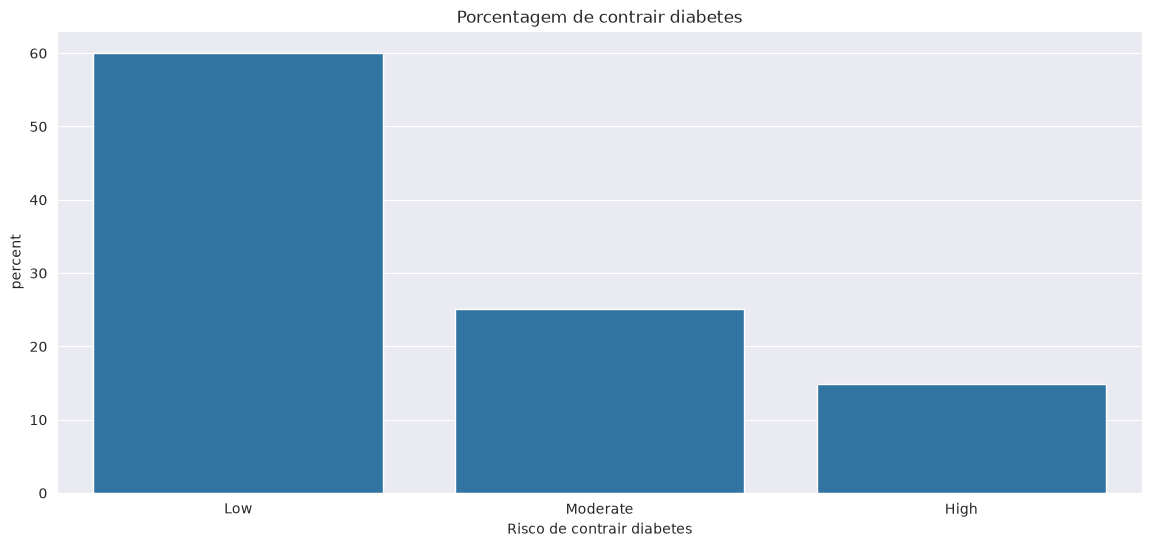

In [12]:
plt.figure(figsize=(14, 6))
plt.title("Porcentagem de contrair diabetes")

ax = sns.countplot(data=data, x="diabetes_risk", stat="percent", order=data["diabetes_risk"].value_counts().index)
ax.set_xlabel("Risco de contrair diabetes")

high = (data["diabetes_risk"] == "High").sum()
moderate = (data["diabetes_risk"] == "Moderate").sum()
low = (data["diabetes_risk"] == "Low").sum()

print("Porcentagens: ")
print(f"Baixo: {(low / data.shape[0]) * 100:.2f}%")
print(f"Moderado: {(moderate / data.shape[0]) * 100:.2f}%")
print(f"Alto: {(high / data.shape[0]) * 100:.2f}%")


Como estão distribuídas as variáveis categóricas?

Error in callback <function _draw_all_if_interactive at 0x739f3a29c400> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

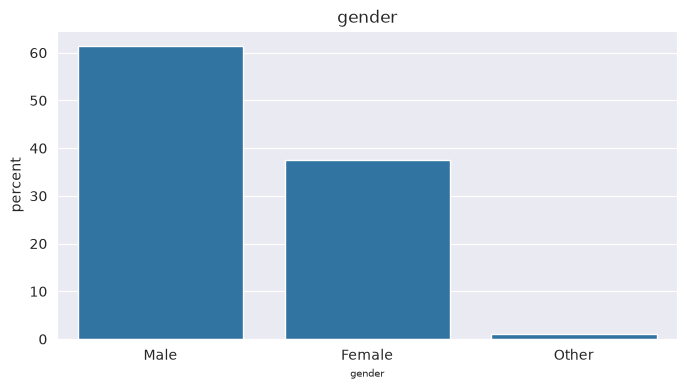

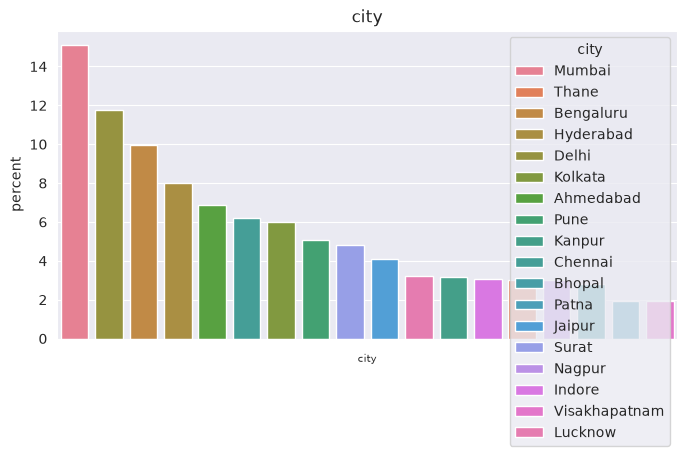

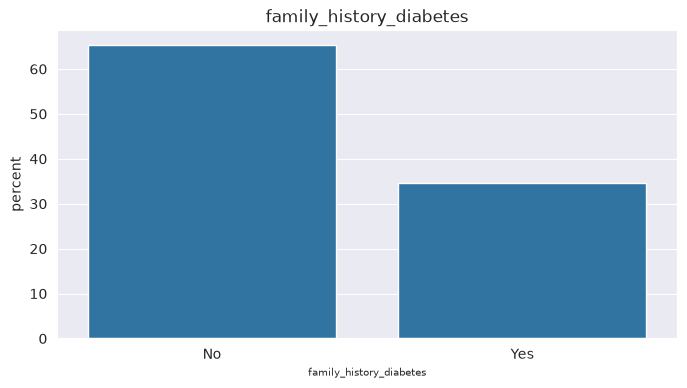

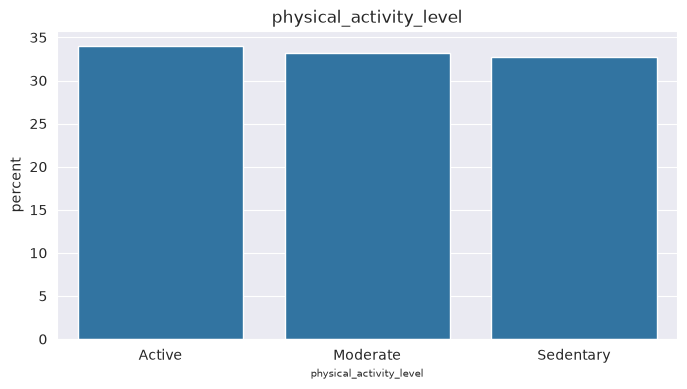

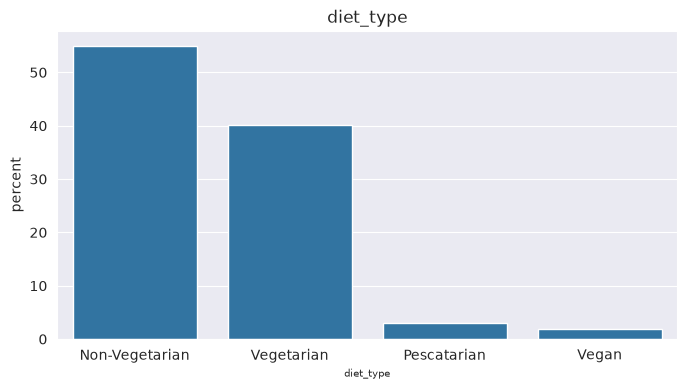

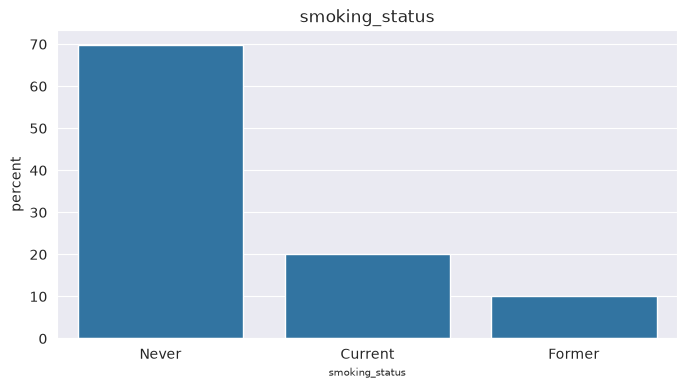

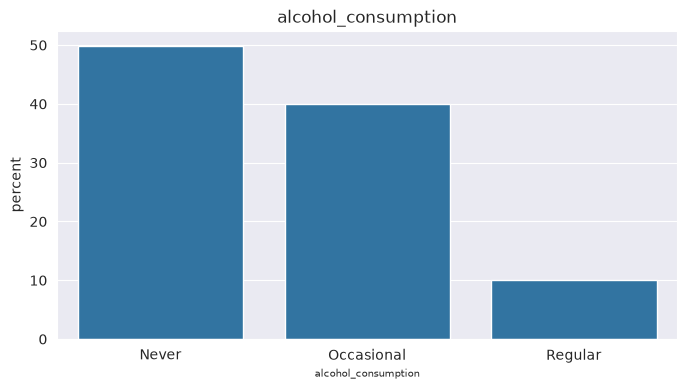

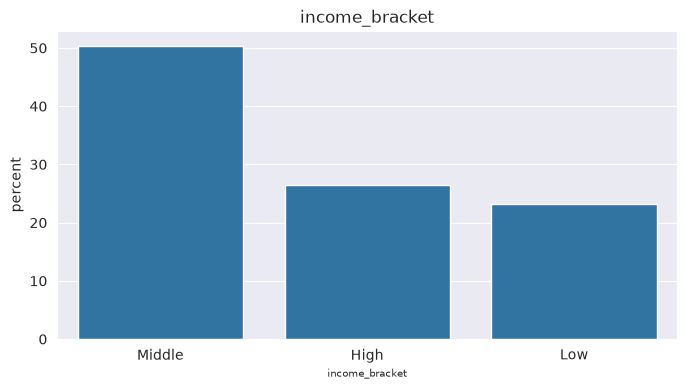

In [13]:
categorical = data.select_dtypes(exclude=["number"])
N_GRAFICOS = categorical.shape[1]
for col in categorical.columns:
    if col != "diabetes_risk":
        plt.figure(figsize=(8, 4))
        plt.title(col)
        if col == "city":
            ax = sns.countplot(data=data, x=col, hue=col, order=data[col].value_counts().index, legend=True, stat="percent")
            ax.set_xticklabels([])
        else:
            ax = sns.countplot(data=data, x=col, order=data[col].value_counts().index, stat="percent")

        ax.set_xlabel(col, fontsize=7)

Pode-se observar alguns valores em algumas categorias que são mais dominantes, mas não há em nenhuma coluna uma grande assimetria na distribuição dos valores.

Distribuição das colunas numéricas

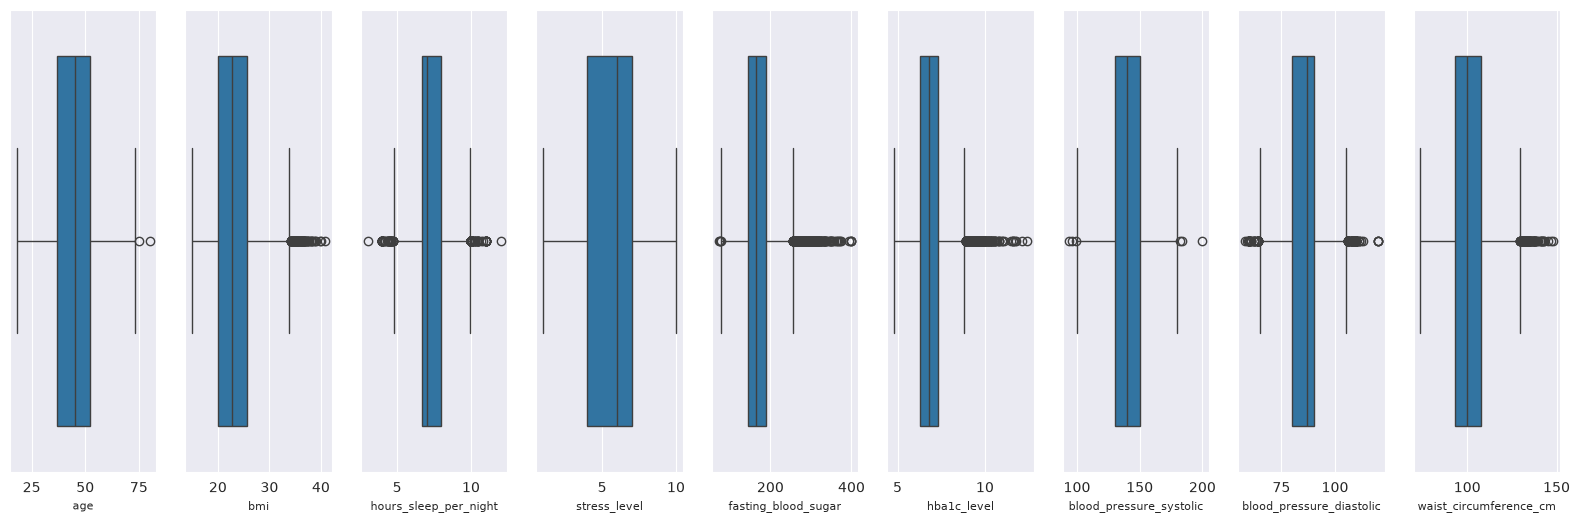

In [ ]:
numeric = data.select_dtypes(include=["number"])
N_GRAFICOS = numeric.shape[1]
fig, axes = plt.subplots(ncols=N_GRAFICOS, figsize=(20, 6))
for id, col in enumerate(numeric.columns, 0):
    ax = sns.boxplot(data=data, x=col, ax = axes[id])
    ax.set_xlabel(col, fontsize=8)

Pelos resultados do gráfico, algumas colunas possuem alguns outliers, como "fasting_blood_sugar" e "hba1c_level", e outras são bem distribuídas, como "age" e "stress_level", que vai apenas de 0 a 10.

A colunas "bmi" e "hba1c_level" estão mais concentradas para a esquerda, já outras como "blood_pressure_systolic" e "blood_pressure_diastolic" estão mais concetradas na parte central da figura.

Relação entre o gênero e idade da pessoa com o risco de contrair diabetes

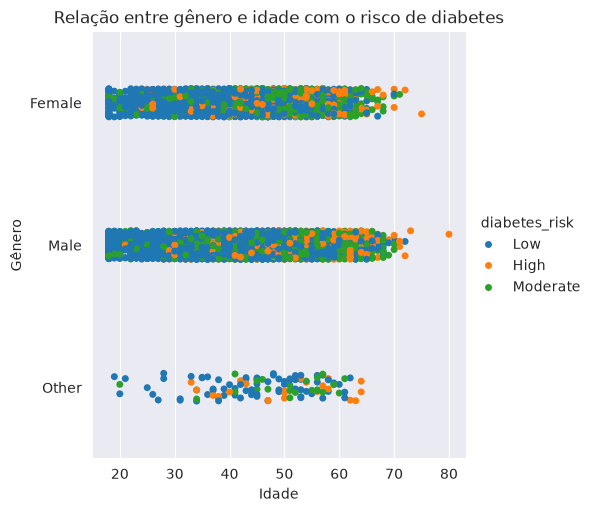

In [ ]:
ax = sns.catplot(data=data, x="age", y="gender", hue="diabetes_risk")
plt.title("Relação entre gênero e idade com o risco de diabetes")
ax.set_xlabels("Idade")
ax.set_ylabels("Gênero")

Claramente é possível verificar que as pessoas mais velhas possuem maior risco de contrair diabetes, mulheres aparentam ter uma taxa um pouquinho maior de alto risco de diabetes.

Existe um relacionamento entre o histórico familiar e o risco de contrair diabetes?

Text(0.5, 0, 'Histórico familiar')

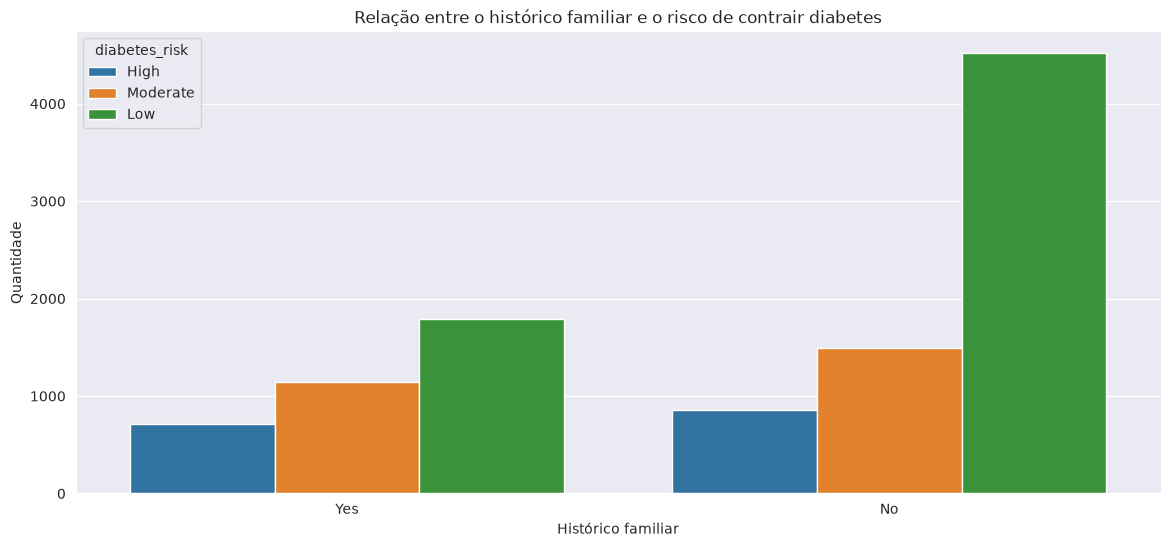

In [23]:
plt.figure(figsize=(14, 6))
sns.countplot(data=data, x="family_history_diabetes", hue="diabetes_risk", hue_order=["High", "Moderate", "Low"])
plt.title("Relação entre o histórico familiar e o risco de contrair diabetes")
plt.ylabel("Quantidade")
plt.xlabel("Histórico familiar")

Com base no gráfico, podemos afimar que não é tão evidente uma relação entre o histórico familiar e o risco de contrair diabetes para pessoas com risco moderado/alto, já para pessoas com risco baixo, o histórico familiar parece importar mais, havendo muito mais pessoas sem histórico familiar com maior risco de contrair diabetes.

Relação do risco de diabetes com BMI, HBA1C e FastingBloodSugar

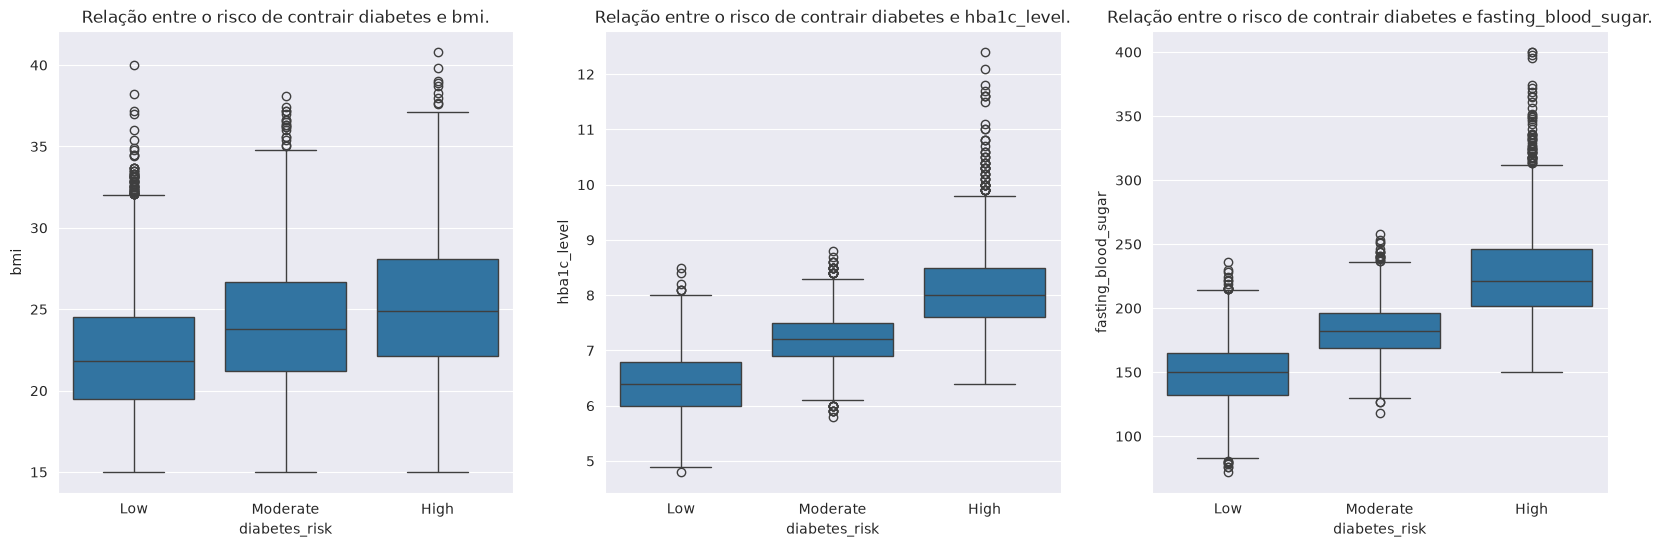

In [ ]:
COLS = ["bmi", "hba1c_level", "fasting_blood_sugar"]
fig, axes = plt.subplots(ncols=3, figsize=(20, 6))

for id, col in enumerate(COLS, 0): 
    ax = sns.boxplot(data=data, x="diabetes_risk", y=col, ax = axes[id], order=data["diabetes_risk"].value_counts().index)
    ax.set_title(f"Relação entre o risco de contrair diabetes e {col}.")

É possível analisar que quando os valores de bmi (índice de massa corporal), hba1c (glicose nos últimos 3 meses) e açúcar no sangue são mais altos, o risco de diabetes é maior. Isso indica que uma combinação alta dessas variáveis com certeza aumenta o risco de contrair diabetes nos pacientes do dataset.

<Axes: title={'center': 'Matriz de correlação entre as colunas numéricas'}>

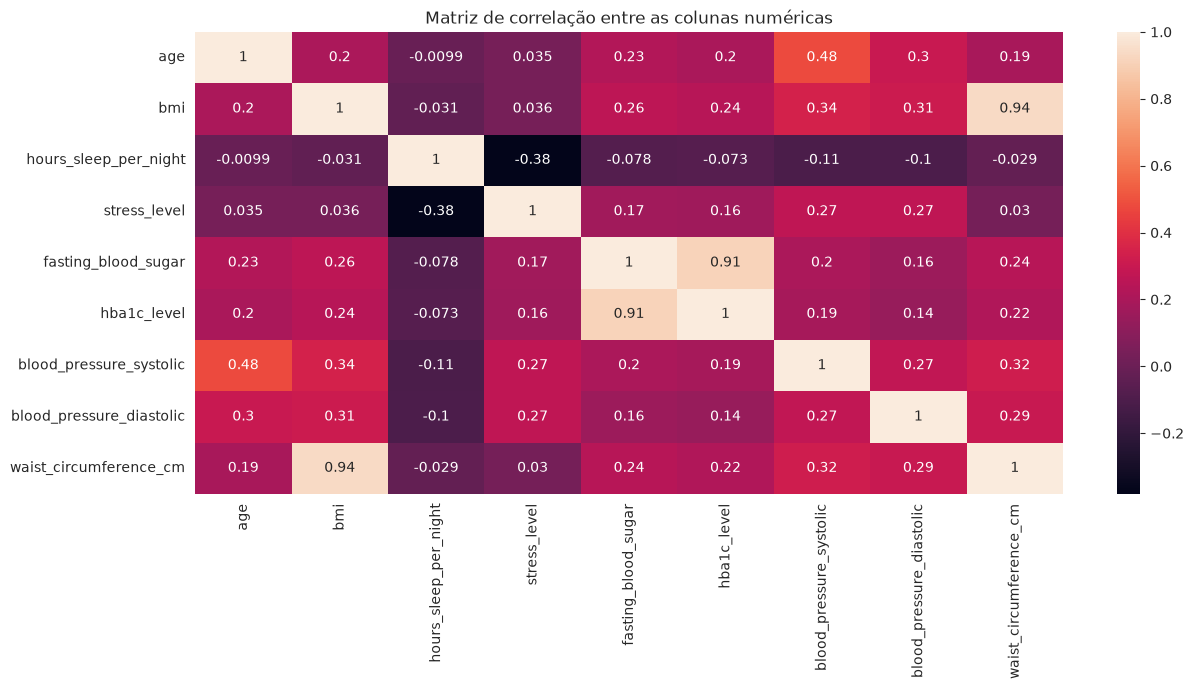

In [ ]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(14, 6))
plt.title("Matriz de correlação entre as colunas numéricas")
sns.heatmap(corr_matrix, annot=True)

Existem algumas correlações bem claras, como uma relação inversamente proporcional entre o nível de estresse e as horas dormidas e a circunferência da cintura com o indíce de massa corporal (bmi).

# Feature Engineering e Classificação

In [ ]:
#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBRegressor

#Util
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

print("Modelos importados")


Modelos importados


In [ ]:
features = ["bmi", "age", "hba1c_level", "fasting_blood_sugar", "family_history_diabetes", "age"]
target = "diabetes_risk"

X = data[features]
X = pd.get_dummies(X, drop_first=True)
y = data[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)

Treinando o modelo

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.fit_transform(X_valid)

model = LogisticRegression(max_iter=1000, random_state=123)
model.fit(X_train, y_train)

preds = model.predict(X_valid)
accuracy = accuracy_score(y_valid, preds)
class_report = classification_report(y_valid, preds)
print(f"Acurácia: {accuracy * 100}%")
print(class_report)

Acurácia: 79.42857142857143%
              precision    recall  f1-score   support

        High       0.84      0.72      0.77       331
         Low       0.85      0.91      0.88      1239
    Moderate       0.61      0.58      0.59       530

    accuracy                           0.79      2100
   macro avg       0.77      0.73      0.75      2100
weighted avg       0.79      0.79      0.79      2100



Matriz de confusão

Text(0.5, 36.38563368055554, 'Predicted')

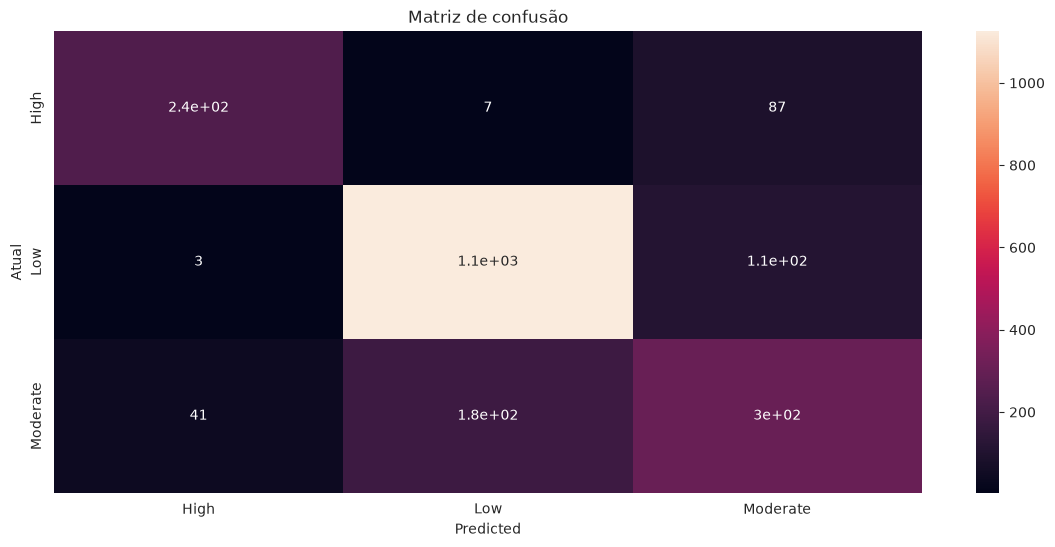

In [ ]:
c = confusion_matrix(y_valid, preds)

plt.figure(figsize=(14, 6))
plt.title("Matriz de confusão")
ax = sns.heatmap(data=c, annot=True, xticklabels=model.classes_, yticklabels=model.classes_)
ax.set_ylabel("Atual")
ax.set_xlabel("Predicted")